In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("merged_dataset.csv")

In [8]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,KERALA,76145.0,93995,3252.4,7246719.65,23604.95,1.147857
1,Black pepper,1997,Whole Year,KERALA,173855.0,55520,3252.4,16545780.35,53895.05,0.240714
2,Cashewnut,1997,Whole Year,KERALA,96073.0,74142,3252.4,9143267.41,29782.63,0.589286
3,Coconut,1997,Whole Year,KERALA,884344.0,5210000000,3252.4,84163018.48,274146.64,5376.054286
4,Tapioca,1997,Whole Year,KERALA,132875.0,2841819,3252.4,12645713.75,41191.25,22.803571


In [9]:
df.shape

(4426, 10)

In [10]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4426 entries, 0 to 4425
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             4426 non-null   object 
 1   Crop_Year        4426 non-null   int64  
 2   Season           4426 non-null   object 
 3   State            4426 non-null   object 
 4   Area             4426 non-null   float64
 5   Production       4426 non-null   int64  
 6   Annual_Rainfall  4426 non-null   float64
 7   Fertilizer       4426 non-null   float64
 8   Pesticide        4426 non-null   float64
 9   Yield            4426 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 345.9+ KB


In [12]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,4426.000000,4.426000e+03,4.426000e+03,4426.000000,4.426000e+03,4.426000e+03,4426.000000
mean,2007.173520,1.253698e+05,3.823297e+07,1335.892431,1.616377e+07,3.125648e+04,71.047134
std,5.259906,4.582274e+05,4.543852e+08,665.133799,6.030059e+07,1.182789e+05,837.473538
min,1997.000000,8.000000e-01,0.000000e+00,301.800000,9.467000e+01,1.700000e-01,0.000000
25%,2003.000000,1.601250e+03,1.573500e+03,956.900000,2.074048e+05,3.659175e+02,0.569500
50%,2007.000000,8.573500e+03,1.201200e+04,1207.000000,1.101392e+06,2.052430e+03,1.012614
75%,2012.000000,6.535600e+04,8.471825e+04,1413.400000,8.293806e+06,1.549762e+04,2.416442
max,2015.000000,4.238204e+06,6.326000e+09,3616.700000,6.599997e+08,1.331781e+06,21105.000000


In [13]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Crop"].unique()
df["Season"].unique()
df["State"].unique()

array(['KERALA', 'TAMIL NADU', 'BIHAR', 'PUNJAB', 'HIMACHAL PRADESH',
       'CHHATTISGARH', 'UTTARAKHAND', 'JHARKHAND', 'TELANGANA',
       'ARUNACHAL PRADESH'], dtype=object)

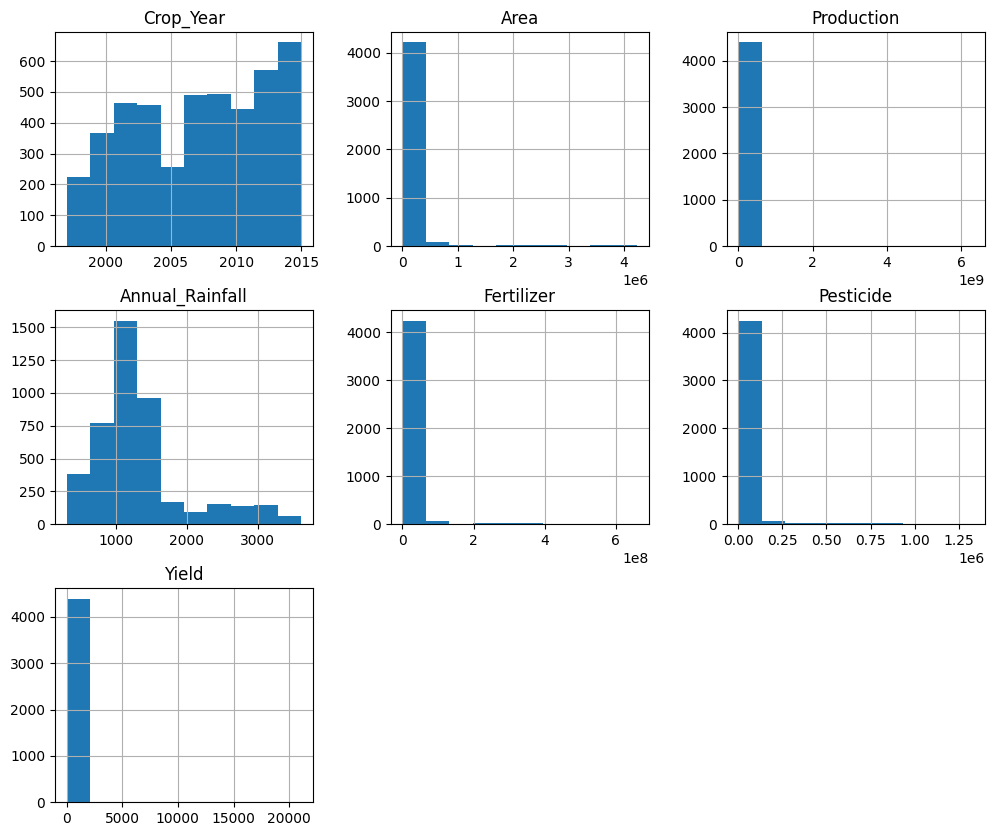

In [16]:
df.hist(figsize=(12,10))
plt.show()

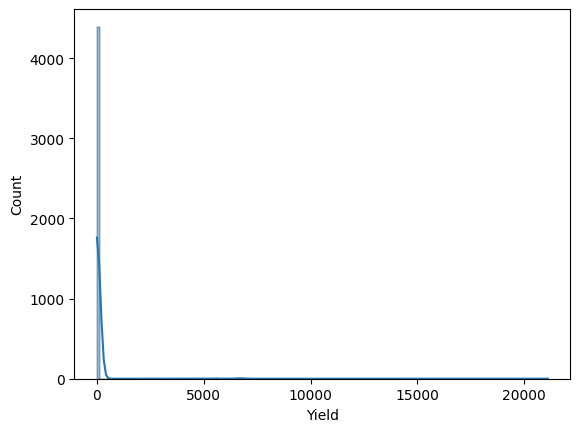

In [18]:
sns.histplot(df["Yield"], kde=True)
plt.show()

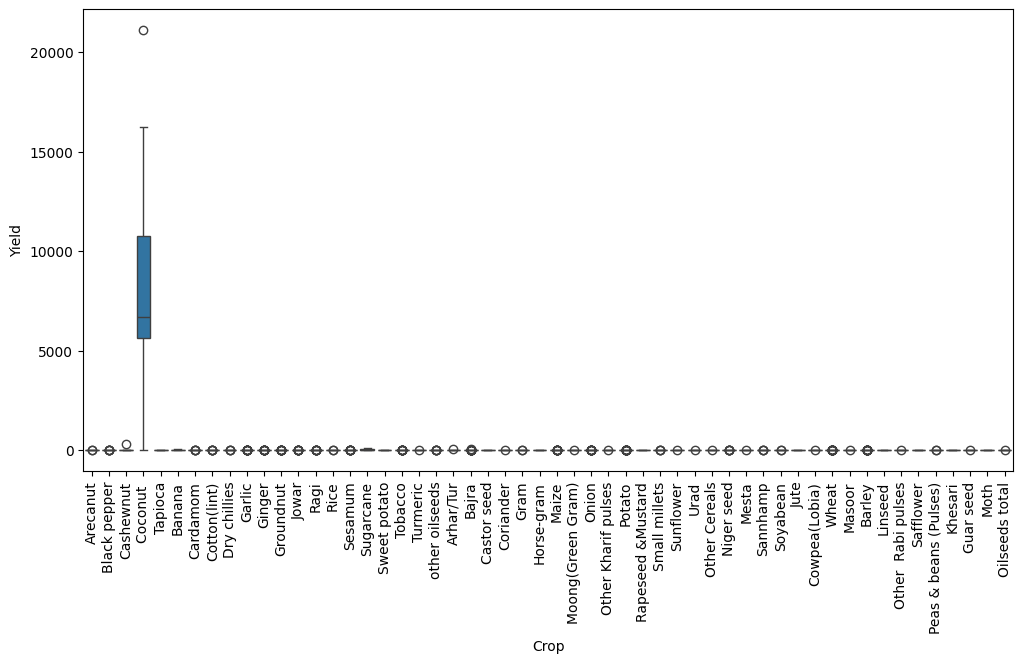

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Crop", y="Yield", data=df)
plt.xticks(rotation=90)
plt.show()

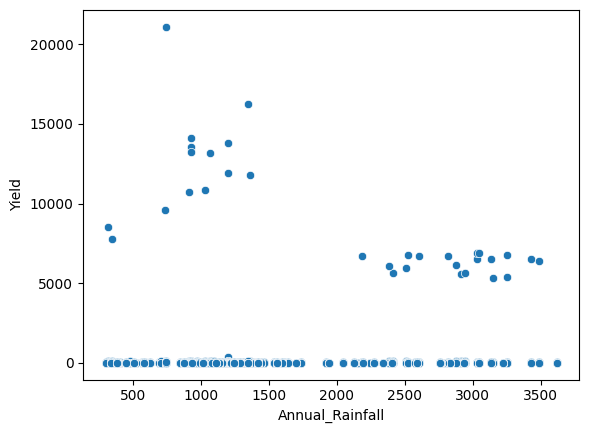

In [20]:
sns.scatterplot(x="Annual_Rainfall", y="Yield", data=df)
plt.show()

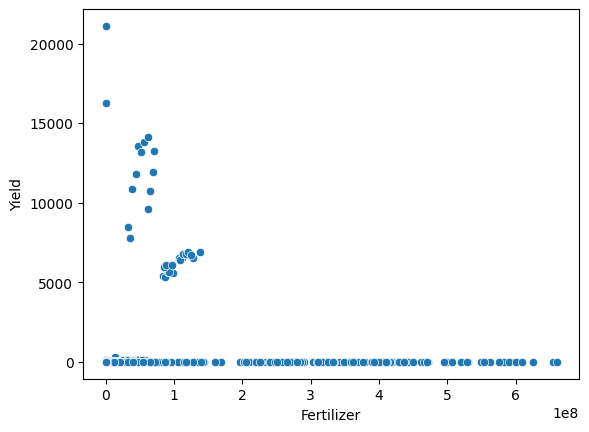

In [21]:
sns.scatterplot(x="Fertilizer", y="Yield", data=df)
plt.show()

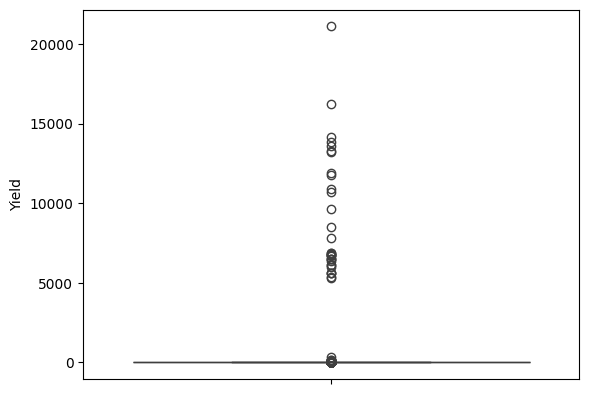

In [22]:
sns.boxplot(df["Yield"])
plt.show()

In [23]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [24]:
df.drop_duplicates(inplace=True)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Crop"] = le.fit_transform(df["Crop"])
df["Season"] = le.fit_transform(df["Season"])
df["State"] = le.fit_transform(df["State"])

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_scaled = scaler.fit_transform(X)

In [29]:
import pickle
pickle.dump(scaler, open("models/scaler.pkl", "wb"))

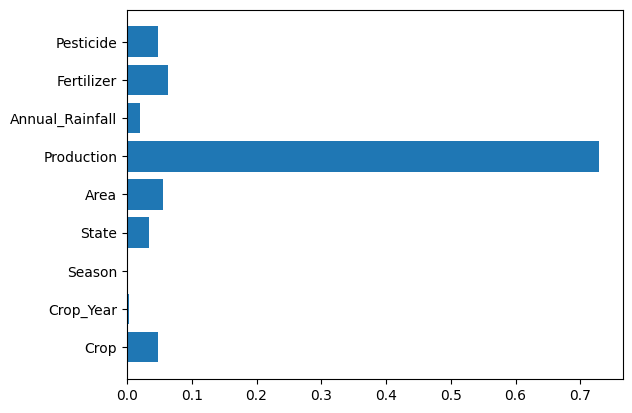

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.show()

NameError: name 'df' is not defined